## Importar bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## Ler as bases de dados

In [220]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")
geolocations = pd.read_csv("../data/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

## Verifica se os datasets foram criados   

In [221]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers
}

for name, df in datasets.items():
    print(name, df.shape)

customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
order_payments (103886, 5)
order_reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)


## Pergunta Norteadora
#### “Quais fatores mais influenciam a satisfação do cliente no e-commerce e como a empresa pode atuar sobre eles para melhorar a experiência e aumentar a fidelização?”

Para explorar a pergunta norteadora vamos trabalhar com 4 de variáveis:

- Categoria do Produto: [product_category_name], disponível na base olist_products_dataset
- Dias de atraso na entrega: Vamos criar a variável [dias_atraso_entrega] =  max(0,[order_delivered_customer_date] - [order_estimated_delivery_date]), disponíveis em olist_orders_dataset
- Valor total da compra: que vai ser a soma dos itens comprados [preco_tota_item] = [price] + [freight_value]obs. Optamos por não utilizar o valor total da compra para manter a granularidade da tabela no nível de item
- Valor do frete: [frete_total] = order_items.groupby("order_id")["freight_value"].sum() disponível na olist_order_items_dataset

Pretendemos descobrir o impacto que essas variáveis possuem em 2 dimensões:

- Experiência do cliente: Vamos considerar com base na avaliação [review_score], disponível na base olist_order_reviews_dataset
- Fidelização: Vamos considerar a recompra de um mesmo cliente em um mesmo vendedor, para isso vamos  criar uma variável binária [cliente_recomprou_mesmo_vendedor] que verifica se um cliente [customer_id], na base olist_orders_dataset, fez mais de uma compra em um mesmo vendedor [seller_id], na base olist_order_items_dataset

No final da análise pretendemos avaliar a relação das 4 variáveis explicativas com o impacto nas 2 variáveis de resultado para responder quais fatores operacionais devem ser priorizados pelos vendedores para maximizar a satisfação e a probabilidade de recompra.


### Preparação dos dados

A Base desejada tem o formato:

        "order_id",
        "order_item_id",
        "product_id",
        "customer_id",
        "seller_id",
        "product_category_name",
        "dias_atraso_entrega",
        "preco_total_item",
        "price",
        "freight_value",
        "review_score",
        "cliente_recomprou_mesmo_vendedor",

Onde um mesmo order_id terá n linhas dependendo da quantidade de itens

In [222]:
# Criando a variável dias_atraso_entrega no df orders

# Tranformando as colunas de data para o formato datetime

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

# Criando a variável dias_atraso_entrega

orders["dias_atraso_entrega"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

orders["dias_atraso_entrega"] = orders["dias_atraso_entrega"].clip(lower=0)


In [223]:
# Juntando pedidos com itens

df = order_items.merge(
    orders[["order_id", "customer_id", "dias_atraso_entrega"]], ###
    on="order_id",
    how="left"
)

In [224]:
# Adicionando categoria dos itens

df = df.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [225]:
# Testando se existem valores duplicados no campo order_id da tabela de avaliações

order_reviews["order_id"].duplicated().sum()


np.int64(551)

In [226]:
# Calculando a média das avaliações por pedido - quando houver mais de uma avaliação para um mesmo pedido
# reviews_unique = order_reviews.groupby("order_id")["review_score"].mean().reset_index()

# Mantem apenas uma avaliação por pedido (a primeira encontrada)
reviews_unique = order_reviews.drop_duplicates(subset="order_id")

# Adicionando a média das avaliações por pedido ao df

df = df.merge(
    reviews_unique[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [227]:
# Criando uma coluna de preço total do item (que é a soma do preço com o frete)
df["preco_total_item"] = df["price"] + df["freight_value"]

In [228]:
# buscando a coluna customer_unique_id para identificar os clientes únicos

df = df.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

In [229]:
# Criando uma coluna indicando se o cliente já comprou mais de uma vez do mesmo vendedor

compras_cliente_seller = df.groupby(
    ["customer_unique_id", "seller_id"]
)["order_id"].nunique().reset_index()

compras_cliente_seller["cliente_recomprou_mesmo_vendedor"] = (
    compras_cliente_seller["order_id"] > 1
).astype(int)

# Adicionando a coluna cliente_recomprou_mesmo_vendedor ao df

df = df.merge(
    compras_cliente_seller[
        ["customer_unique_id", "seller_id", "cliente_recomprou_mesmo_vendedor"]
    ],
    on=["customer_unique_id", "seller_id"],
    how="left"
)

In [230]:
# Selecionando colunas relevantes para análise

df_final = df[
    [
        "order_id",
        "order_item_id",
        "product_id",
        "customer_id",
        "customer_unique_id",
        "seller_id",
        "product_category_name",
        "dias_atraso_entrega",
        "preco_total_item",
        "price",
        "freight_value",
        "review_score",
        "cliente_recomprou_mesmo_vendedor",
    ]
]

In [231]:
df_final.head()

,order_id,order_item_id,product_id,customer_id,customer_unique_id,seller_id,product_category_name,dias_atraso_entrega,preco_total_item,price,freight_value,review_score,cliente_recomprou_mesmo_vendedor
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,48436dade18ac8b2bce089ec2a041202,cool_stuff,0.000000,72.190000,58.900000,13.290000,5.000000,0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,0.000000,259.830000,239.900000,19.930000,4.000000,0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,5b51032eddd242adc84c38acab88f23d,moveis_decoracao,0.000000,216.870000,199.000000,17.870000,5.000000,0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,9d7a1d34a5052409006425275ba1c2b4,perfumaria,0.000000,25.780000,12.990000,12.790000,4.000000,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,df560393f3a51e74553ab94004ba5c87,ferramentas_jardim,0.000000,218.040000,199.900000,18.140000,5.000000,0


### Entendendo as variáveis de resultado

In [232]:
df_final["review_score"].value_counts(normalize=True)

review_score
5.000000   0.565519
4.000000   0.189807
1.000000   0.126464
3.000000   0.083808
2.000000   0.034402
Name: proportion, dtype: float64

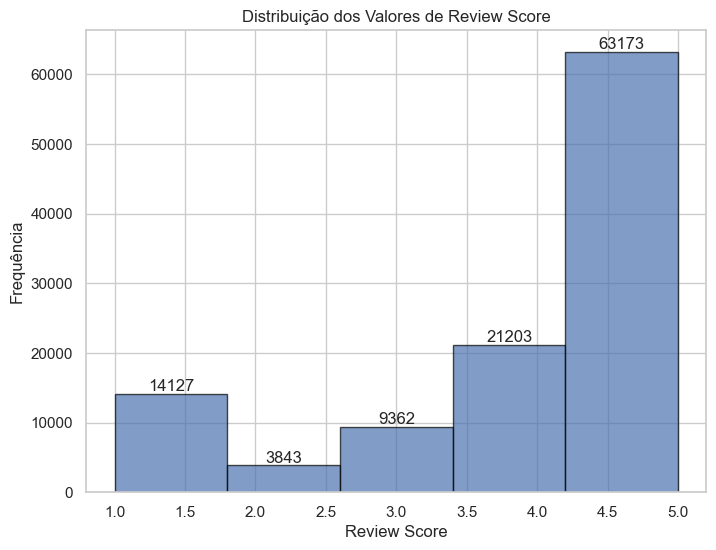

In [233]:
# Histograma da distribuição dos valores de review_score

plt.figure(figsize=(8, 6))

counts, bins, patches = plt.hist(
    df_final['review_score'].dropna(),
    bins=5,
    edgecolor='black',
    alpha=0.7
)

# Adiciona rótulos de frequência em cada barra
plt.bar_label(patches, fmt='%.0f')

plt.title('Distribuição dos Valores de Review Score')
plt.xlabel('Review Score')
plt.ylabel('Frequência')
plt.grid(True)

plt.show()

In [ ]:
# Inforações de recompra
taxa = df_final["cliente_recomprou_mesmo_vendedor"].mean() * 100
print(f"Taxa de recompra: {taxa:.2f}%")
print()

print("Soma de clientes que recompraram:", df_final["cliente_recomprou_mesmo_vendedor"].sum())
print()

print("Distribuição:")
print(df_final["cliente_recomprou_mesmo_vendedor"].value_counts(dropna=False))
print()

print("Clientes com mais de um pedido:")
print(
    df_final.groupby("customer_unique_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head()
)

Taxa de recompra: 2.06%

Soma da recompra: 2322

Distribuição:
cliente_recomprou_mesmo_vendedor
0    110328
1      2322
Name: count, dtype: int64

Clientes com mais de um pedido:
customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    16
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
Name: order_id, dtype: int64


### Começando as análises

#### Categoria do Produto

In [ ]:
# Avaliação média por categoria de produto

avaliacao_por_categoria = (
    df_final
    .groupby("product_category_name")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

avaliacao_por_categoria.head(10)

product_category_name
cds_dvds_musicais                    4.642857
fashion_roupa_infanto_juvenil        4.500000
livros_interesse_geral               4.446266
construcao_ferramentas_ferramentas   4.444444
flores                               4.419355
livros_importados                    4.400000
livros_tecnicos                      4.363636
malas_acessorios                     4.315257
alimentos_bebidas                    4.310469
portateis_casa_forno_e_cafe          4.302632
Name: review_score, dtype: float64

In [243]:
# Recompra por categoria de produto

recompra_por_categoria = (
    df_final
    .groupby("product_category_name")["cliente_recomprou_mesmo_vendedor"]
    .mean()
    .sort_values(ascending=False)
)

recompra_por_categoria.head(10)

product_category_name
fraldas_higiene                 0.256410
artes_e_artesanato              0.166667
eletrodomesticos                0.142672
fashion_roupa_infanto_juvenil   0.125000
musica                          0.078947
casa_conforto_2                 0.066667
moveis_quarto                   0.055046
fashion_bolsas_e_acessorios     0.054653
dvds_blu_ray                    0.046875
alimentos                       0.043137
Name: cliente_recomprou_mesmo_vendedor, dtype: float64

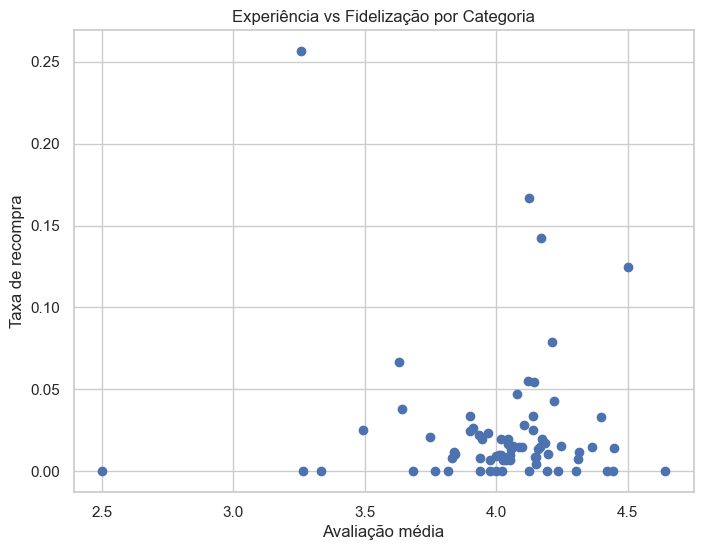

In [ ]:
# Juntando a availação média e a taxa de recompra por categoria para análise conjunta

resumo_categoria = (
    df_final
    .groupby("product_category_name")
    .agg({
        "review_score": "mean",
        "cliente_recomprou_mesmo_vendedor": "mean"
    })
    .rename(columns={
        "review_score": "avaliacao_media",
        "cliente_recomprou_mesmo_vendedor": "taxa_recompra"
    })
)

plt.figure(figsize=(8,6))
plt.scatter(
    resumo_categoria["avaliacao_media"],
    resumo_categoria["taxa_recompra"]
)

plt.xlabel("Avaliação média")
plt.ylabel("Taxa de recompra")
plt.title("Experiência vs Fidelização por Categoria")
plt.grid(True)
plt.show()

A análise de dispersão entre avaliação média e taxa de recompra por categoria não evidenciou uma correlação linear forte entre satisfação e fidelização. Observou-se que diversas categorias apresentam avaliações elevadas, porém com baixa taxa de recompra, sugerindo que a natureza do produto — e não apenas a experiência — influencia o comportamento de retorno do cliente.

### Dias de atraso na entrega

In [254]:
# Retira atrasos maiores que 30 dias para evitar distorção na análise de avaliação por atraso
df_atraso_filtrado = df_final[
    df_final["dias_atraso_entrega"] <= 30
]

# Calcula a avaliação média por dias de atraso
atraso_vs_review = (
    df_atraso_filtrado
    .groupby("dias_atraso_entrega")["review_score"]
    .mean()
    .reset_index()
)

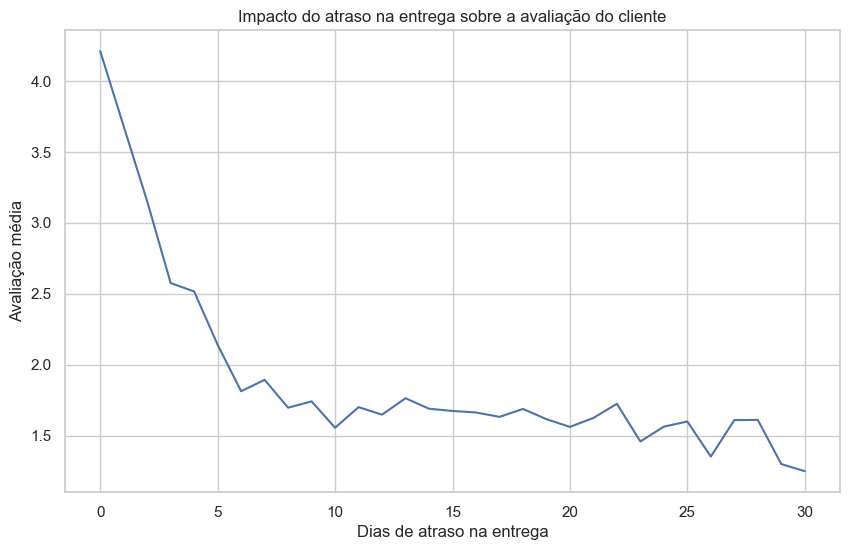

In [255]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    atraso_vs_review["dias_atraso_entrega"],
    atraso_vs_review["review_score"]
)

plt.xlabel("Dias de atraso na entrega")
plt.ylabel("Avaliação média")
plt.title("Impacto do atraso na entrega sobre a avaliação do cliente")
plt.grid(True)

plt.show()

In [259]:
print("Avaliação média para entregas no prazo:", df_final[df_final["dias_atraso_entrega"] == 0]["review_score"].mean())
print("Avaliação média para entregas com atraso:", df_final[df_final["dias_atraso_entrega"] > 0]["review_score"].mean())


Avaliação média para entregas no prazo: 4.208750061103778
Avaliação média para entregas com atraso: 2.2571993224167137


A análise da relação entre o atraso na entrega e a avaliação média dos pedidos evidenciou uma forte correlação negativa. Observou-se que mesmo pequenos atrasos de 2 a 3 dias resultam em quedas expressivas na avaliação média, que passa de valores superiores a 4 para níveis próximos a 2. Após aproximadamente uma semana de atraso, a avaliação se estabiliza em patamares baixos, indicando que o cliente já percebeu a experiência como insatisfatória.